<a href="https://colab.research.google.com/github/Harshita-ami/Decode_labs/blob/main/DECODELABSP3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

%matplotlib inline

In [3]:
from google.colab import files
uploaded = files.upload()  # choose Mall_Customers.csv from your computer

df = pd.read_csv('Mall_Customers.csv')
df.head()

Saving Mall_Customers.csv to Mall_Customers.csv


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
print(df.shape)
df.info()
df.describe()

(200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
# Typically: Age, Annual Income, Spending Score
# Drop CustomerID (not useful) and Gender (categorical, optional to encode later)
features = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
features.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [7]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

scaled_df = pd.DataFrame(scaled_features, columns=features.columns)
scaled_df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


In [8]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)

print("Explained variance by each component:", pca.explained_variance_ratio_)
print("Total variance retained:", sum(pca.explained_variance_ratio_))

pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_df.head()

Explained variance by each component: [0.44266167 0.33308378]
Total variance retained: 0.7757454566976747


,PC1,PC2
0,-0.615720,-1.763481
1,-1.665793,-1.820747
2,0.337862,-1.674799
3,-1.456573,-1.772430
4,-0.038465,-1.662740


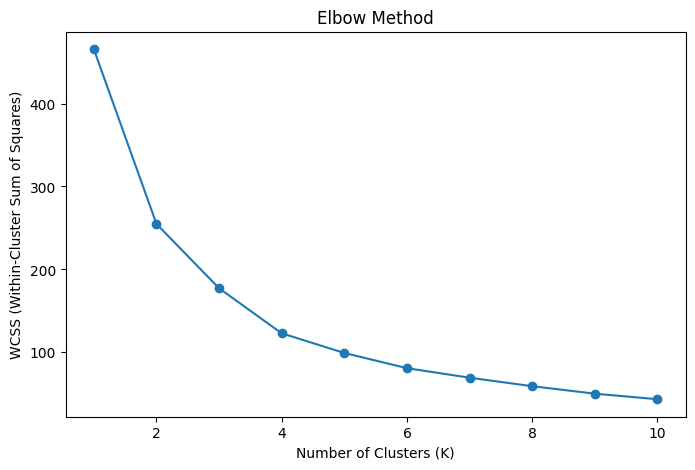

In [9]:
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(pca_result)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.title('Elbow Method')
plt.show()

K=2, Silhouette Score=0.4256
K=3, Silhouette Score=0.4136
K=4, Silhouette Score=0.4209
K=5, Silhouette Score=0.3931
K=6, Silhouette Score=0.3775
K=7, Silhouette Score=0.3871
K=8, Silhouette Score=0.3976
K=9, Silhouette Score=0.3899
K=10, Silhouette Score=0.4038


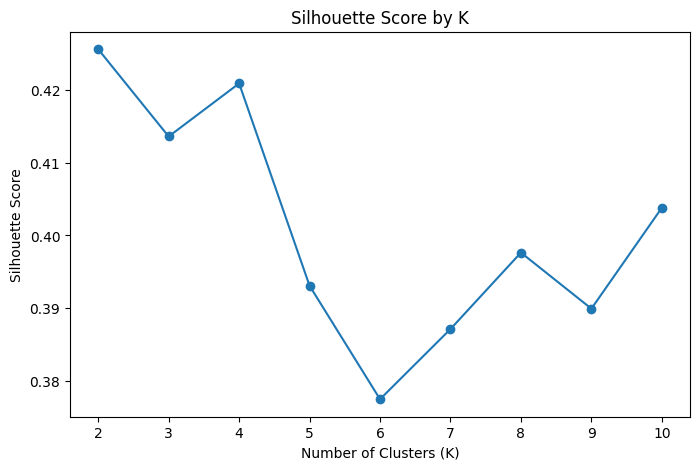

In [10]:
silhouette_scores = []

for k in range(2, 11):  # silhouette needs at least 2 clusters
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(pca_result)
    score = silhouette_score(pca_result, labels)
    silhouette_scores.append(score)
    print(f"K={k}, Silhouette Score={score:.4f}")

plt.figure(figsize=(8,5))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by K')
plt.show()

In [11]:
optimal_k = 5  # <-- update this based on what Cell 7 & 8 showed you

kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(pca_result)

df['Cluster'] = cluster_labels
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,4
2,3,Female,20,16,6,0
3,4,Female,23,16,77,4
4,5,Female,31,17,40,4


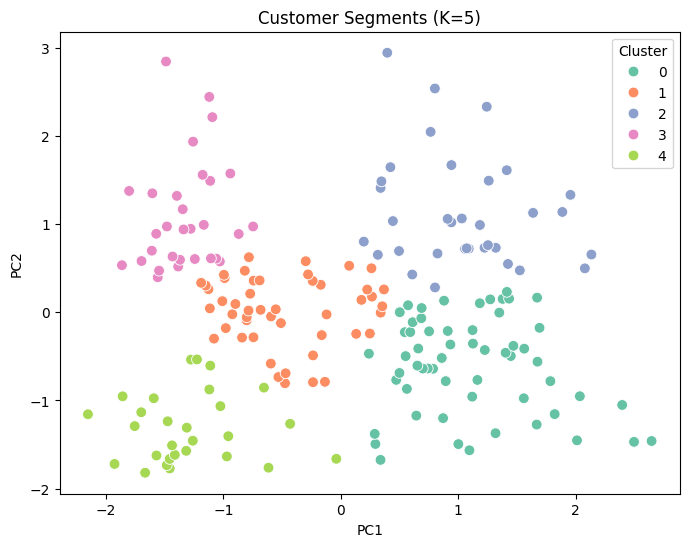

In [12]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=cluster_labels, palette='Set2', s=60)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'Customer Segments (K={optimal_k})')
plt.legend(title='Cluster')
plt.show()

In [13]:
cluster_summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
cluster_summary['Count'] = df['Cluster'].value_counts()
cluster_summary

,Age,Annual Income (k$),Spending Score (1-100),Count
Cluster,,,,
0,53.559322,43.779661,38.508475,59
1,30.489796,61.551020,52.612245,49
2,43.264706,88.470588,18.617647,34
3,31.733333,90.866667,83.266667,30
4,24.750000,27.821429,73.535714,28


In [14]:
for i in range(optimal_k):
    cluster_data = cluster_summary.loc[i]
    print(f"\nCluster {i}:")
    print(f"  Avg Age: {cluster_data['Age']:.1f}")
    print(f"  Avg Income: ${cluster_data['Annual Income (k$)']:.1f}k")
    print(f"  Avg Spending Score: {cluster_data['Spending Score (1-100)']:.1f}")
    print(f"  Number of Customers: {int(cluster_data['Count'])}")


Cluster 0:
  Avg Age: 53.6
  Avg Income: $43.8k
  Avg Spending Score: 38.5
  Number of Customers: 59

Cluster 1:
  Avg Age: 30.5
  Avg Income: $61.6k
  Avg Spending Score: 52.6
  Number of Customers: 49

Cluster 2:
  Avg Age: 43.3
  Avg Income: $88.5k
  Avg Spending Score: 18.6
  Number of Customers: 34

Cluster 3:
  Avg Age: 31.7
  Avg Income: $90.9k
  Avg Spending Score: 83.3
  Number of Customers: 30

Cluster 4:
  Avg Age: 24.8
  Avg Income: $27.8k
  Avg Spending Score: 73.5
  Number of Customers: 28
